Sinal Freqs Ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Ruído (H1) Freqs Ajustadas: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]
FP Ref (H0) Freqs Ajustadas: [ 41.015625  50.78125   60.546875  70.3125   101.5625   111.328125
 121.09375  130.859375]
Calculando limiar da MSC e PFA/TN global (H0)...
  H0 trial 1000/10000
  H0 trial 2000/10000
  H0 trial 3000/10000
  H0 trial 4000/10000
  H0 trial 5000/10000
  H0 trial 6000/10000
  H0 trial 7000/10000
  H0 trial 8000/10000
  H0 trial 9000/10000
  H0 trial 10000/10000
Limiar MSC: 0.4293 (Tempo H0: 6.98s)
PFA Empírica Global (H0): 0.0500
TN Rate Global (H0 - Especificidade): 0.9500
Calculando PD/FN (Sinal) e FP/TN (Ruído em H1)...
  SNR=-25.0dB: PD_M=0.006, FP_H1_M=0.0069
  SNR=-23.0dB: PD_M=0.009, FP_H1_M=0.0069
  SNR=-21.0dB: PD_M=0.008, FP_H1_M=0.0073
  SNR=-19.0dB: PD_M=0.007, FP_H1_M=0.0046
  SNR=-17.0dB: PD_M=0.009, FP_H1_M=0.0071
  SNR=-15.0dB:

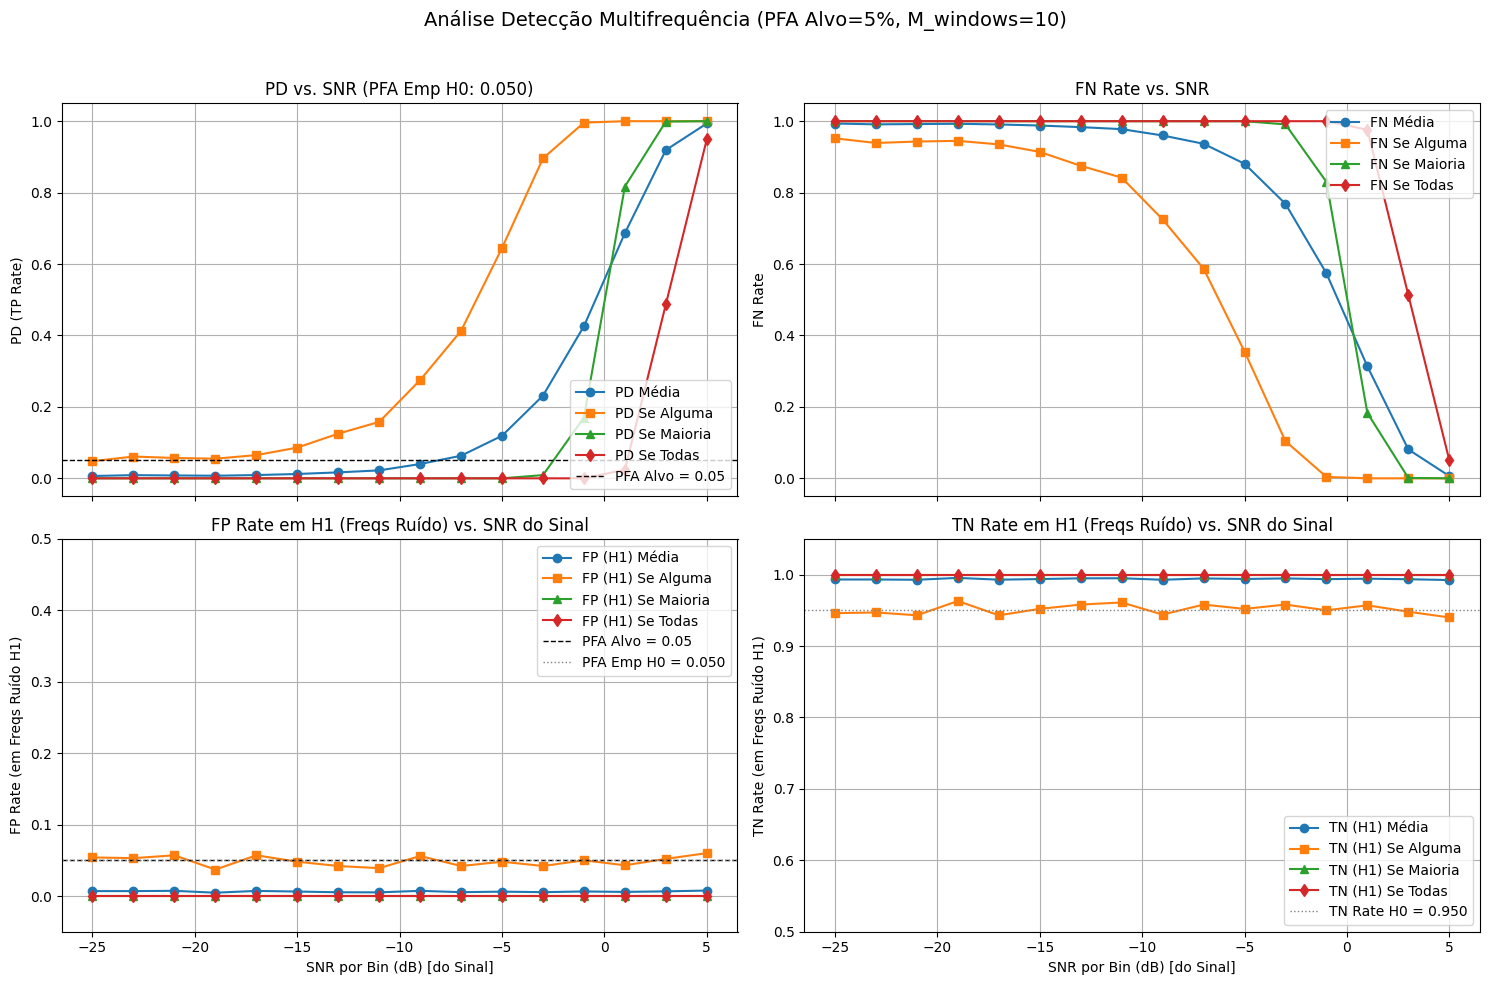

Simulação com análise completa concluída.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Funções Auxiliares (msc_fft_py e wilson_score_interval_py da resposta anterior) ---
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0 or np.isnan(n) or np.isnan(k): return np.nan, (np.nan, np.nan)
    k = np.nan_to_num(k) # Tratar NaN em k, se houver
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1 - term2) / denominator)
    pci_u = min(1, (term1 + term2) / denominator)
    return phat, (pci_l, pci_u)

# --- Parâmetros da Simulação ---
FS = 1000; NFFT_msc = 512; M_windows = 10
signal_frequencies_nominal = np.array([82, 84, 86, 88, 90, 92, 94, 96])
noise_only_frequencies_nominal = np.array([41, 51, 61, 71, 101, 111, 121, 131])
fp_reference_frequencies_nominal = noise_only_frequencies_nominal.copy()

num_signal_freqs = len(signal_frequencies_nominal)
num_noise_only_freqs = len(noise_only_frequencies_nominal)
num_fp_ref_freqs = len(fp_reference_frequencies_nominal)

target_pfa = 0.05
N_trials_H0 = 10000
N_master_trials_H1 = 1000
snr_db_per_bin_range = np.arange(-25, 5 + 1, 2)

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS
hanning_win_msc = np.hanning(NFFT_msc)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT, FS_rate):
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT
        bin_indices[i] = bin_idx_ideal # Para rfft, este é o índice direto
    return adj_freqs, bin_indices

signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT_msc, FS)
noise_only_frequencies_adj, noise_only_bin_indices_py = adjust_freqs_get_bins_py(noise_only_frequencies_nominal, NFFT_msc, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT_msc, FS)

print(f"Sinal Freqs Ajustadas: {signal_frequencies_adj}")
print(f"Ruído (H1) Freqs Ajustadas: {noise_only_frequencies_adj}")
print(f"FP Ref (H0) Freqs Ajustadas: {fp_reference_frequencies_adj}")

# --- Parte 1: Determinação do Limiar e PFA/TN Empírica Global (H0) ---
print(f'Calculando limiar da MSC e PFA/TN global (H0)...')
start_time_h0 = time.time()
max_msc_values_H0_at_fp_ref_freqs = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0
for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc; end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        Y_fft_H0_all_windows[:, k] = np.fft.rfft(window_data * hanning_win_msc)
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    valid_indices_h0 = fp_ref_bin_indices_py[(fp_ref_bin_indices_py >= 0) & (fp_ref_bin_indices_py < len(msc_spectrum_H0))]
    if msc_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_ref_freqs:
        msc_at_fp_ref_bins = msc_spectrum_H0[valid_indices_h0]
        max_msc_values_H0_at_fp_ref_freqs[i] = np.max(msc_at_fp_ref_bins)
    else: max_msc_values_H0_at_fp_ref_freqs[i] = np.nan
    if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0}')
valid_msc_H0 = max_msc_values_H0_at_fp_ref_freqs[~np.isnan(max_msc_values_H0_at_fp_ref_freqs)]
if len(valid_msc_H0) == 0: raise ValueError("Não foi possível calcular valores de MSC para H0.")
threshold_msc = scoreatpercentile(valid_msc_H0, (1 - target_pfa) * 100)
num_false_positives_global_H0 = np.sum(valid_msc_H0 > threshold_msc)
pfa_empirical_global_H0 = num_false_positives_global_H0 / len(valid_msc_H0)
tn_rate_global_H0 = 1 - pfa_empirical_global_H0
end_time_h0 = time.time()
print(f'Limiar MSC: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')
print(f'PFA Empírica Global (H0): {pfa_empirical_global_H0:.4f}')
print(f'TN Rate Global (H0 - Especificidade): {tn_rate_global_H0:.4f}')

# --- Parte 2: Cálculo de PD/FN (Sinal) e FP/TN (Ruído em H1) ---
criteria_names = ['Média', 'Se Alguma', 'Se Maioria', 'Se Todas']
num_criteria = len(criteria_names)
results_H1 = {}
for name in criteria_names:
    results_H1[name] = {
        'PD': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'PD_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'FN_Rate': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FN_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'FP_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'FP_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
        'TN_Rate_H1': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_lower': np.zeros(len(snr_db_per_bin_range)), 'TN_H1_ic_upper': np.zeros(len(snr_db_per_bin_range)),
    }
P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD/FN (Sinal) e FP/TN (Ruído em H1)...')
start_time_h1_total = time.time()
for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr_loop = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    
    total_signal_detections_individual_agg = 0
    master_trial_signal_detections_any_agg = 0
    master_trial_signal_detections_majority_agg = 0
    master_trial_signal_detections_all_agg = 0
    
    total_noise_fp_individual_agg = 0
    master_trial_noise_fp_any_agg = 0
    master_trial_noise_fp_majority_agg = 0
    master_trial_noise_fp_all_agg = 0

    for master_trial in range(N_master_trials_H1):
        individual_signal_detections_this_master_trial_list = [] # Para um master trial
        individual_noise_fp_this_master_trial_list = [] # Para um master trial
        
        # O espectro de ruído (e portanto FP/TN nas noise_only_freqs) será o mesmo para todas as injeções de sinal neste master_trial
        # Geramos UM sinal de ruído de fundo para o master_trial
        n_t_all_windows_master = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
        
        # Precisamos de um espectro de referência para o ruído do master_trial
        # para avaliar FP/TN nas noise_only_frequencies
        Y_fft_noise_master_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
        for k_win in range(M_windows):
            start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
            window_data_noise = n_t_all_windows_master[start_idx:end_idx] # Apenas ruído
            Y_fft_noise_master_all_windows[:, k_win] = np.fft.rfft(window_data_noise * hanning_win_msc)
        msc_spectrum_noise_master = msc_fft_py(Y_fft_noise_master_all_windows, M_windows)

        msc_at_noise_only_bins_master = msc_spectrum_noise_master[noise_only_bin_indices_py]
        fp_results_for_noise_bins_master = (msc_at_noise_only_bins_master > threshold_msc).astype(int)
        
        total_noise_fp_individual_agg += np.sum(fp_results_for_noise_bins_master)
        num_fp_in_noise_master_trial = np.sum(fp_results_for_noise_bins_master)
        if num_fp_in_noise_master_trial > 0: master_trial_noise_fp_any_agg += 1
        if num_fp_in_noise_master_trial > (num_noise_only_freqs / 2): master_trial_noise_fp_majority_agg += 1
        if num_fp_in_noise_master_trial == num_noise_only_freqs: master_trial_noise_fp_all_agg += 1

        for sig_f_idx in range(num_signal_freqs):
            current_f_signal = signal_frequencies_adj[sig_f_idx]
            current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
            s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal * t_msc_segment)
            s_t_all_windows = np.tile(s_t_single_window, M_windows)
            x_t_all_windows = s_t_all_windows + n_t_all_windows_master # Sinal + mesmo ruído do master_trial
            
            Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
                window_data = x_t_all_windows[start_idx:end_idx]
                Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win_msc)
            msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
            
            current_msc_at_signal_bin = np.nan
            if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >= 0:
                 current_msc_at_signal_bin = msc_spectrum_H1[current_signal_actual_bin]
            if not np.isnan(current_msc_at_signal_bin) and current_msc_at_signal_bin > threshold_msc:
                individual_signal_detections_this_master_trial_list.append(1)
            else:
                individual_signal_detections_this_master_trial_list.append(0)
        
        num_detected_signals_in_master_trial = np.sum(individual_signal_detections_this_master_trial_list)
        total_signal_detections_individual_agg += num_detected_signals_in_master_trial
        if num_detected_signals_in_master_trial > 0: master_trial_signal_detections_any_agg += 1
        if num_detected_signals_in_master_trial > (num_signal_freqs / 2): master_trial_signal_detections_majority_agg += 1
        if num_detected_signals_in_master_trial == num_signal_freqs: master_trial_signal_detections_all_agg += 1
            
    # Calcular Taxas e ICs para PD/FN
    counts_PD = [total_signal_detections_individual_agg, master_trial_signal_detections_any_agg, master_trial_signal_detections_majority_agg, master_trial_signal_detections_all_agg]
    n_PD_denominators = [N_master_trials_H1 * num_signal_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
    for c_idx, crit_name in enumerate(criteria_names):
        pd_val, (pci_l, pci_u) = wilson_score_interval_py(counts_PD[c_idx], n_PD_denominators[c_idx])
        results_H1[crit_name]['PD'][snr_idx] = pd_val
        results_H1[crit_name]['PD_ic_lower'][snr_idx] = pci_l; results_H1[crit_name]['PD_ic_upper'][snr_idx] = pci_u
        results_H1[crit_name]['FN_Rate'][snr_idx] = 1 - pd_val if not np.isnan(pd_val) else np.nan
        results_H1[crit_name]['FN_ic_lower'][snr_idx] = 1 - pci_u if not np.isnan(pci_u) else np.nan
        results_H1[crit_name]['FN_ic_upper'][snr_idx] = 1 - pci_l if not np.isnan(pci_l) else np.nan

    # Calcular Taxas e ICs para FP/TN em H1
    counts_FP_H1 = [total_noise_fp_individual_agg, master_trial_noise_fp_any_agg, master_trial_noise_fp_majority_agg, master_trial_noise_fp_all_agg]
    n_FP_H1_denominators = [N_master_trials_H1 * num_noise_only_freqs, N_master_trials_H1, N_master_trials_H1, N_master_trials_H1]
    for c_idx, crit_name in enumerate(criteria_names):
        fp_val, (fp_l, fp_u) = wilson_score_interval_py(counts_FP_H1[c_idx], n_FP_H1_denominators[c_idx])
        results_H1[crit_name]['FP_Rate_H1'][snr_idx] = fp_val
        results_H1[crit_name]['FP_H1_ic_lower'][snr_idx] = fp_l; results_H1[crit_name]['FP_H1_ic_upper'][snr_idx] = fp_u
        results_H1[crit_name]['TN_Rate_H1'][snr_idx] = 1 - fp_val if not np.isnan(fp_val) else np.nan
        results_H1[crit_name]['TN_H1_ic_lower'][snr_idx] = 1 - fp_u if not np.isnan(fp_u) else np.nan
        results_H1[crit_name]['TN_H1_ic_upper'][snr_idx] = 1 - fp_l if not np.isnan(fp_l) else np.nan
    
    print(f'  SNR={current_snr_db:.1f}dB: PD_M={results_H1["Média"]["PD"][snr_idx]:.3f}, FP_H1_M={results_H1["Média"]["FP_Rate_H1"][snr_idx]:.4f}')
end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True) # 2x2 grid
plot_styles = ['-o', '-s', '-^', '-d']
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

ax_map = {'PD': axs[0,0], 'FN_Rate': axs[0,1], 'FP_Rate_H1': axs[1,0], 'TN_Rate_H1': axs[1,1]}
y_labels = {'PD': 'PD (TP Rate)', 'FN_Rate': 'FN Rate', 'FP_Rate_H1': 'FP Rate (em Freqs Ruído H1)', 'TN_Rate_H1': 'TN Rate (em Freqs Ruído H1)'}
titles = {
    'PD': f'PD vs. SNR (PFA Emp H0: {pfa_empirical_global_H0:.3f})',
    'FN_Rate': 'FN Rate vs. SNR',
    'FP_Rate_H1': 'FP Rate em H1 (Freqs Ruído) vs. SNR do Sinal',
    'TN_Rate_H1': 'TN Rate em H1 (Freqs Ruído) vs. SNR do Sinal'
}
y_lims = {'PD': [-0.05, 1.05], 'FN_Rate': [-0.05, 1.05], 'FP_Rate_H1': [-0.05, 0.5], 'TN_Rate_H1': [0.5, 1.05]} # Ajustar Ylims
legend_locs = {'PD': 'lower right', 'FN_Rate': 'upper right', 'FP_Rate_H1': 'upper right', 'TN_Rate_H1': 'lower right'}


for rate_type in ['PD', 'FN_Rate', 'FP_Rate_H1', 'TN_Rate_H1']:
    ax = ax_map[rate_type]
    for c_idx, crit_name in enumerate(criteria_names):
        label_prefix = ""
        if rate_type == 'PD': label_prefix = "PD "
        elif rate_type == 'FN_Rate': label_prefix = "FN "
        elif rate_type == 'FP_Rate_H1': label_prefix = "FP (H1) "
        elif rate_type == 'TN_Rate_H1': label_prefix = "TN (H1) "

        ax.plot(snr_db_per_bin_range, results_H1[crit_name][rate_type], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=f"{label_prefix}{crit_name}")
        # ax.fill_between(snr_db_per_bin_range, results_H1[crit_name][f'{rate_type}_ic_lower'], results_H1[crit_name][f'{rate_type}_ic_upper'],
        #                 color=colors[c_idx % len(colors)], alpha=0.15)
    
    if rate_type == 'PD' or rate_type == 'FP_Rate_H1': # Linha de referência PFA
        ax.axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
    if rate_type == 'FP_Rate_H1':
        ax.axhline(pfa_empirical_global_H0, color='grey', linestyle=':', linewidth=1, label=f'PFA Emp H0 = {pfa_empirical_global_H0:.3f}')
    if rate_type == 'TN_Rate_H1':
        ax.axhline(tn_rate_global_H0, color='grey', linestyle=':', linewidth=1, label=f'TN Rate H0 = {tn_rate_global_H0:.3f}')

    ax.set_ylabel(y_labels[rate_type])
    ax.set_title(titles[rate_type])
    ax.legend(loc=legend_locs[rate_type])
    ax.grid(True)
    ax.set_ylim(y_lims[rate_type])
    if rate_type.startswith('FP') or rate_type.startswith('TN'): # Apenas os últimos subplots precisam do xlabel
         ax.set_xlabel('SNR por Bin (dB) [do Sinal]')


fig.suptitle(f'Análise Detecção Multifrequência (PFA Alvo={target_pfa*100:.0f}%, M_windows={M_windows})', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Simulação com análise completa concluída.')

Frequências de FP ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Frequências de Sinal ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Calculando limiar da MSC e PFA/TN empírica (H0)...
  H0 trial 1000/10000
  H0 trial 2000/10000
  H0 trial 3000/10000
  H0 trial 4000/10000
  H0 trial 5000/10000
  H0 trial 6000/10000
  H0 trial 7000/10000
  H0 trial 8000/10000
  H0 trial 9000/10000
  H0 trial 10000/10000
Limiar MSC: 0.4186 (Tempo H0: 28.03s)
PFA Empírica (H0): 0.0500 (FP Rate)
Taxa de Verdadeiro Negativo (H0 - Especificidade): 0.9500
Calculando PD e FN Rate para diferentes SNRs e Critérios (H1)...
  SNR=-25.0dB: PD_M=0.007, PD_Any=0.056, PD_Maj=0.000, PD_All=0.000
  SNR=-23.0dB: PD_M=0.007, PD_Any=0.059, PD_Maj=0.000, PD_All=0.000
  SNR=-21.0dB: PD_M=0.008, PD_Any=0.066, PD_Maj=0.000, PD_All=0.000
  SNR=-19.0dB: PD_M=0.011, PD_Any=0.088, PD_Maj=0.000, PD_All=0.000
  SNR=-17.0dB: PD_M=0.012, PD_Any=0.089,

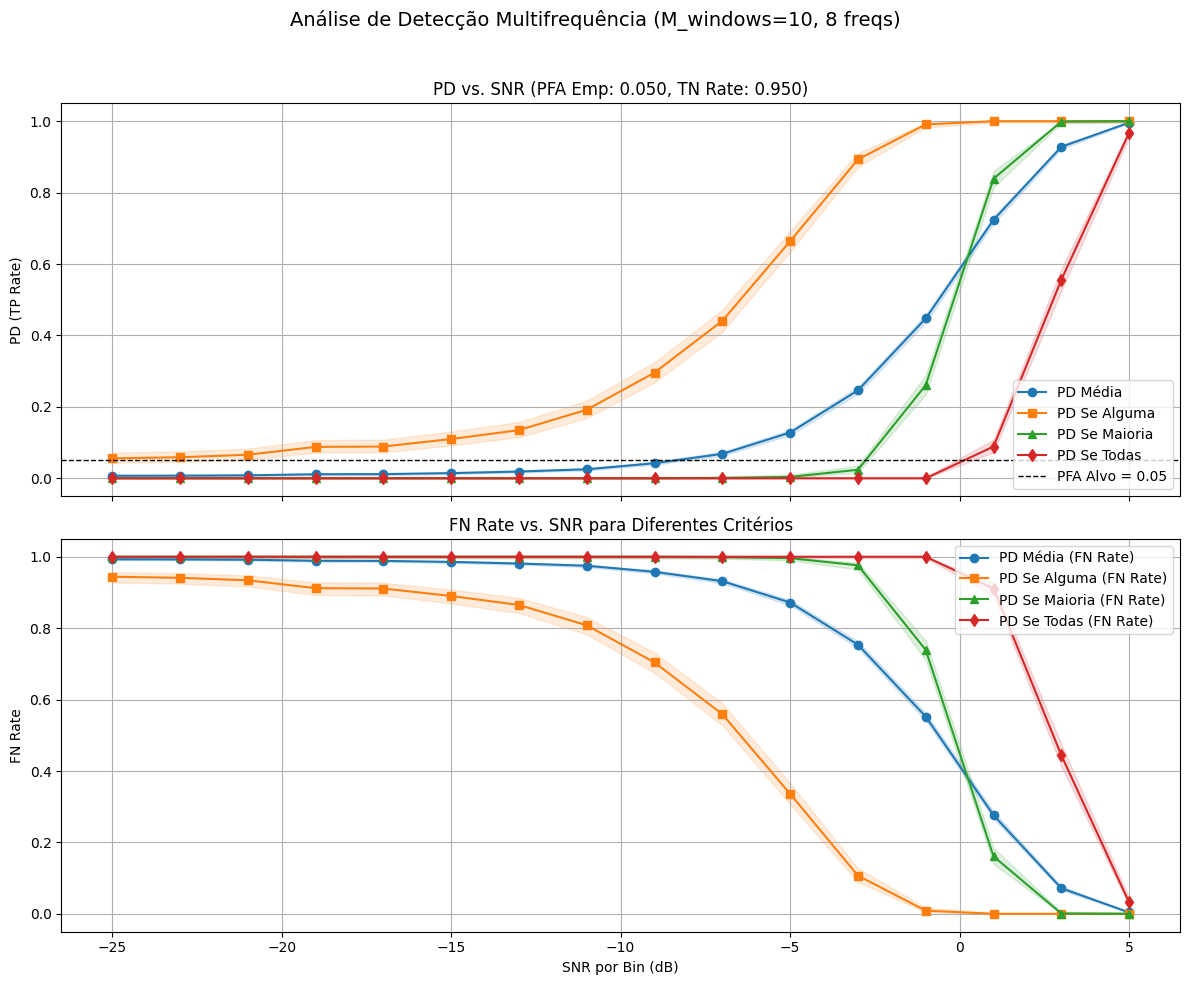

Simulação com análise de FN concluída.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Funções Auxiliares (msc_fft_py e wilson_score_interval_py da resposta anterior) ---
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0: return np.nan, (np.nan, np.nan)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1 - term2) / denominator)
    pci_u = min(1, (term1 + term2) / denominator)
    return phat, (pci_l, pci_u)

# --- Parâmetros da Simulação (mesmos da resposta anterior) ---
FS = 1000; NFFT_msc = 512; M_windows = 10
signal_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
fp_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
num_signal_freqs = len(signal_frequencies)
num_fp_freqs = len(fp_frequencies)
target_pfa = 0.05
N_trials_H0 = 10000
N_master_trials_H1 = 1000
snr_db_per_bin_range = np.arange(-25, 5 + 1, 2)

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS
hanning_win_msc = np.hanning(NFFT_msc)

fp_bin_indices_py = np.zeros(num_fp_freqs, dtype=int)
fp_frequencies_adj = np.zeros(num_fp_freqs)
for i, f_val in enumerate(fp_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    fp_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    fp_bin_indices_py[i] = bin_idx_ideal
signal_bin_indices_py = np.zeros(num_signal_freqs, dtype=int)
signal_frequencies_adj = np.zeros(num_signal_freqs)
for i, f_val in enumerate(signal_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    signal_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    signal_bin_indices_py[i] = bin_idx_ideal
print(f"Frequências de FP ajustadas: {fp_frequencies_adj}")
print(f"Frequências de Sinal ajustadas: {signal_frequencies_adj}")

# --- Parte 1: Determinação do Limiar e PFA/TN Empírica (H0) ---
print(f'Calculando limiar da MSC e PFA/TN empírica (H0)...')
start_time_h0 = time.time()
max_msc_values_H0_at_fp_freqs = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0
for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc; end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        Y_fft_H0_all_windows[:, k] = np.fft.rfft(window_data * hanning_win_msc)
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    valid_indices_h0 = fp_bin_indices_py[(fp_bin_indices_py >= 0) & (fp_bin_indices_py < len(msc_spectrum_H0))]
    if msc_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_freqs:
        msc_at_fp_bins = msc_spectrum_H0[valid_indices_h0]
        max_msc_values_H0_at_fp_freqs[i] = np.max(msc_at_fp_bins)
    else: max_msc_values_H0_at_fp_freqs[i] = np.nan
    if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0}')
valid_msc_H0 = max_msc_values_H0_at_fp_freqs[~np.isnan(max_msc_values_H0_at_fp_freqs)]
if len(valid_msc_H0) == 0: raise ValueError("Não foi possível calcular valores de MSC para H0.")
threshold_msc = scoreatpercentile(valid_msc_H0, (1 - target_pfa) * 100)
num_false_positives_H0 = np.sum(valid_msc_H0 > threshold_msc)
pfa_empirical_H0 = num_false_positives_H0 / len(valid_msc_H0)
tn_rate_H0 = 1 - pfa_empirical_H0
end_time_h0 = time.time()
print(f'Limiar MSC: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')
print(f'PFA Empírica (H0): {pfa_empirical_H0:.4f} (FP Rate)')
print(f'Taxa de Verdadeiro Negativo (H0 - Especificidade): {tn_rate_H0:.4f}')

# --- Parte 2: Cálculo da PD e FN Rate para diferentes Critérios (H1) ---
pd_crit_list = [] 
fn_crit_list = []
criteria_names = ['PD Média', 'PD Se Alguma', 'PD Se Maioria', 'PD Se Todas']
num_criteria = len(criteria_names)
for name in criteria_names:
    pd_crit_list.append({'name': name, 'values': np.zeros(len(snr_db_per_bin_range)), 'ic_lower': np.zeros(len(snr_db_per_bin_range)), 'ic_upper': np.zeros(len(snr_db_per_bin_range))})
    fn_crit_list.append({'name': f'{name} (FN Rate)', 'values': np.zeros(len(snr_db_per_bin_range)), 'ic_lower': np.zeros(len(snr_db_per_bin_range)), 'ic_upper': np.zeros(len(snr_db_per_bin_range))})
P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD e FN Rate para diferentes SNRs e Critérios (H1)...')
start_time_h1_total = time.time()
for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr_loop = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    detections_count_crit = np.zeros(num_criteria, dtype=int)
    for master_trial in range(N_master_trials_H1):
        individual_detections_this_master_trial = np.zeros(num_signal_freqs, dtype=int)
        for sig_f_idx in range(num_signal_freqs):
            current_f_signal = signal_frequencies_adj[sig_f_idx]
            current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
            s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal * t_msc_segment)
            s_t_all_windows = np.tile(s_t_single_window, M_windows)
            n_t_all_windows = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
            x_t_all_windows = s_t_all_windows + n_t_all_windows
            Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
                window_data = x_t_all_windows[start_idx:end_idx]
                Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win_msc)
            msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
            current_msc_at_signal_bin = np.nan
            if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >= 0:
                 current_msc_at_signal_bin = msc_spectrum_H1[current_signal_actual_bin]
            if not np.isnan(current_msc_at_signal_bin) and current_msc_at_signal_bin > threshold_msc:
                individual_detections_this_master_trial[sig_f_idx] = 1
        num_detected_in_master_trial = np.sum(individual_detections_this_master_trial)
        detections_count_crit[0] += num_detected_in_master_trial
        if num_detected_in_master_trial > 0: detections_count_crit[1] += 1
        if num_detected_in_master_trial > (num_signal_freqs / 2): detections_count_crit[2] += 1
        if num_detected_in_master_trial == num_signal_freqs: detections_count_crit[3] += 1
            
    total_individual_detection_opportunities = N_master_trials_H1 * num_signal_freqs
    pd_val1, (pci_l1, pci_u1) = wilson_score_interval_py(detections_count_crit[0], total_individual_detection_opportunities)
    pd_crit_list[0]['values'][snr_idx] = pd_val1
    pd_crit_list[0]['ic_lower'][snr_idx] = pci_l1; pd_crit_list[0]['ic_upper'][snr_idx] = pci_u1
    fn_crit_list[0]['values'][snr_idx] = 1 - pd_val1
    fn_crit_list[0]['ic_lower'][snr_idx] = 1 - pci_u1; fn_crit_list[0]['ic_upper'][snr_idx] = 1 - pci_l1

    for c_idx in range(1, num_criteria):
        pd_val, (pci_l, pci_u) = wilson_score_interval_py(detections_count_crit[c_idx], N_master_trials_H1)
        pd_crit_list[c_idx]['values'][snr_idx] = pd_val
        pd_crit_list[c_idx]['ic_lower'][snr_idx] = pci_l; pd_crit_list[c_idx]['ic_upper'][snr_idx] = pci_u
        fn_crit_list[c_idx]['values'][snr_idx] = 1 - pd_val
        fn_crit_list[c_idx]['ic_lower'][snr_idx] = 1 - pci_u; fn_crit_list[c_idx]['ic_upper'][snr_idx] = 1 - pci_l
    
    print(f'  SNR={current_snr_db:.1f}dB: PD_M={pd_crit_list[0]["values"][snr_idx]:.3f}, PD_Any={pd_crit_list[1]["values"][snr_idx]:.3f}, PD_Maj={pd_crit_list[2]["values"][snr_idx]:.3f}, PD_All={pd_crit_list[3]["values"][snr_idx]:.3f}')
end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
plot_styles = ['-o', '-s', '-^', '-d']
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Gráfico 1: PD (TP Rate) vs SNR
for c_idx in range(num_criteria):
    axs[0].plot(snr_db_per_bin_range, pd_crit_list[c_idx]['values'], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=pd_crit_list[c_idx]['name'])
    axs[0].fill_between(snr_db_per_bin_range, pd_crit_list[c_idx]['ic_lower'], pd_crit_list[c_idx]['ic_upper'],
                        color=colors[c_idx % len(colors)], alpha=0.15)
axs[0].axhline(target_pfa, color='k', linestyle='--', linewidth=1, label=f'PFA Alvo = {target_pfa:.2f}')
axs[0].set_ylabel('PD (TP Rate)')
axs[0].set_title(f'PD vs. SNR (PFA Emp: {pfa_empirical_H0:.3f}, TN Rate: {tn_rate_H0:.3f})')
axs[0].legend(loc='lower right')
axs[0].grid(True)
axs[0].set_ylim([-0.05, 1.05])

# Gráfico 2: FN Rate vs SNR
for c_idx in range(num_criteria):
    axs[1].plot(snr_db_per_bin_range, fn_crit_list[c_idx]['values'], plot_styles[c_idx],
                color=colors[c_idx % len(colors)], linewidth=1.5, label=fn_crit_list[c_idx]['name']) # Usa cores PD
    axs[1].fill_between(snr_db_per_bin_range, fn_crit_list[c_idx]['ic_lower'], fn_crit_list[c_idx]['ic_upper'],
                        color=colors[c_idx % len(colors)], alpha=0.15)
axs[1].set_xlabel('SNR por Bin (dB)')
axs[1].set_ylabel('FN Rate')
axs[1].set_title('FN Rate vs. SNR para Diferentes Critérios')
axs[1].legend(loc='upper right')
axs[1].grid(True)
axs[1].set_ylim([-0.05, 1.05])

fig.suptitle(f'Análise de Detecção Multifrequência (M_windows={M_windows}, {num_signal_freqs} freqs)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para suptitle
plt.show()

print('Simulação com análise de FN concluída.')